In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../jhani_pandit_dataset/Fitness_Survey__Responses_clean.xlsx')

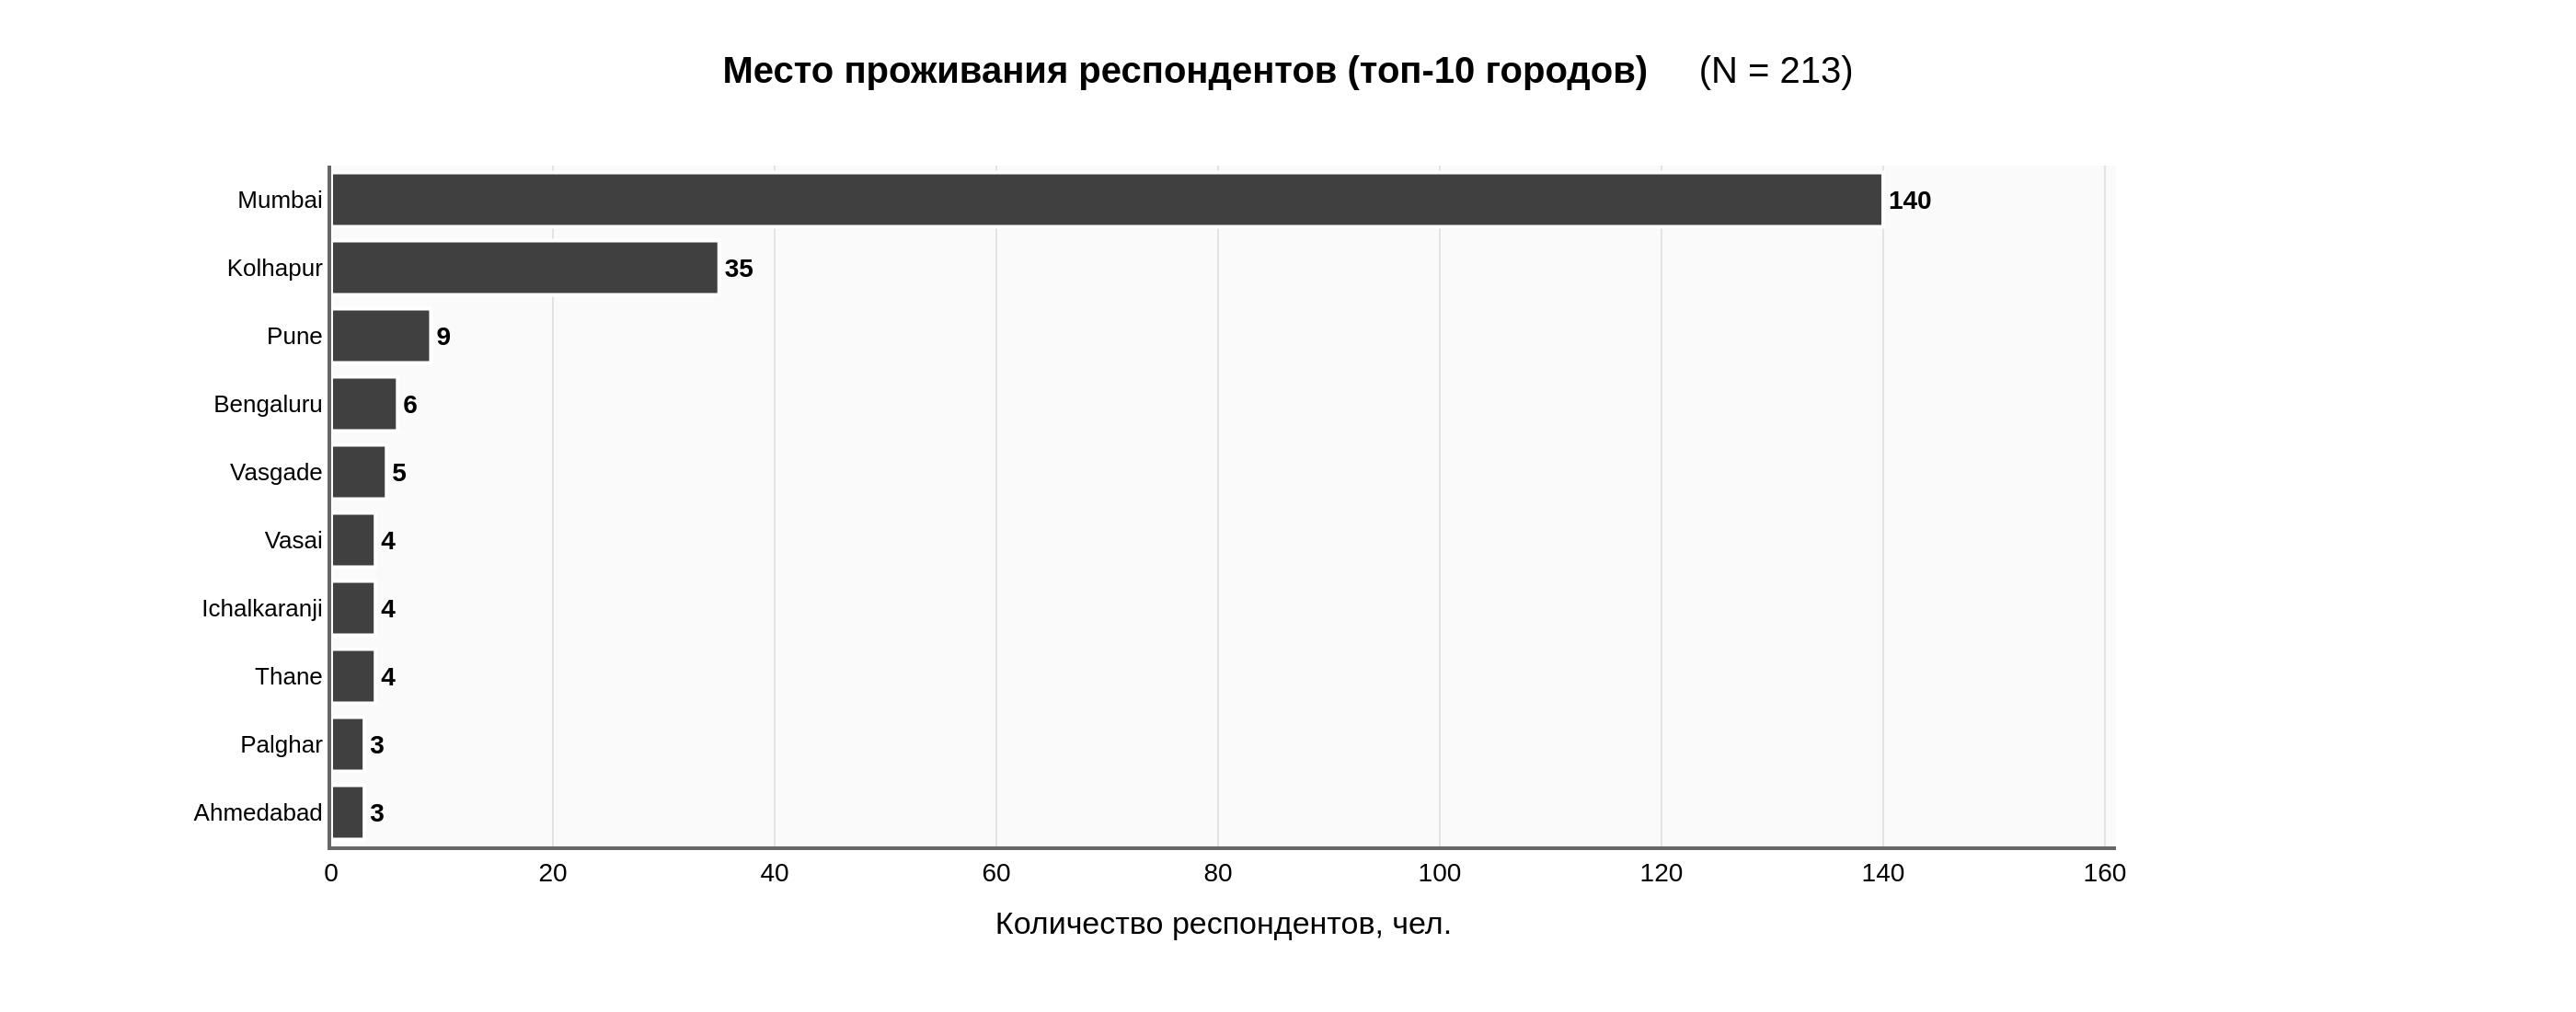

In [2]:
col = "Location_norm"

counts = (
    df[col]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
    .head(10)
)

counts_sorted = counts.sort_values(ascending=True)

fig = go.Figure(data=[go.Bar(
    y=counts_sorted.index,
    x=counts_sorted.values,
    orientation='h',
    text=[f'<b>{count}</b>' for count in counts_sorted.values],
    textposition='outside',
    textfont=dict(size=14, color='#000000'),
    marker=dict(color=PRIMARY, line=dict(color='white', width=2)),
    hovertemplate='<b>%{y}</b><br>Количество: %{x} чел.<extra></extra>'
)])

fig.update_layout(
    title={
        'text': f'<b>Место проживания респондентов (топ-10 городов)</b>     (N = {int(counts.sum())})',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'color': '#000000', 'family': 'Arial'}
    },
    xaxis_title='Количество респондентов, чел.',
    yaxis_title='',
    height=550,
    width=1400,
    paper_bgcolor='white',
    plot_bgcolor='rgba(245,245,245,0.5)',
    font=dict(family='Arial', size=14, color='#000000'),
    xaxis=dict(
        showgrid=True,
        gridcolor=GRID_COLOR,
        linecolor=AXIS_COLOR,
        linewidth=2,
        range=[0, max(counts_sorted.values) * 1.15]
    ),
    yaxis=dict(
        showgrid=False,
        linecolor=AXIS_COLOR,
        linewidth=2,
        tickfont=dict(size=13)
    ),
    margin=dict(l=180, r=250, t=90, b=90)
)
fig.show()